In [91]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [92]:
df = pd.read_csv('training.csv')
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

In [97]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Training Accuracy:", accuracy_score(y_train, model.predict(X_train)))
print("Validation Accuracy:", accuracy_score(y_valid, model.predict(X_valid)))

Training Accuracy: 1.0
Validation Accuracy: 0.975


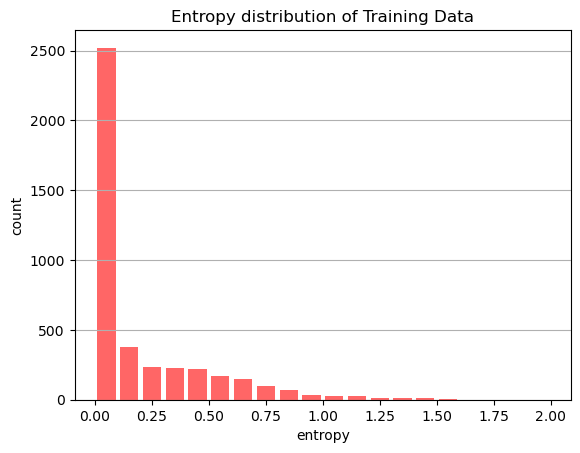

In [122]:
model = models[0]
pred_probs = model.predict_proba(X)
entropies = np.apply_along_axis(entropy, 1, pred_probs)

bins = np.linspace(0, 2, 21)
plt.figure()
plt.grid(axis='y')
plt.hist(entropies, bins=bins, rwidth=0.8, alpha=0.6, color='red')
plt.xlabel('entropy')
plt.ylabel('count')
plt.title('Entropy distribution of Training Data')
plt.show()

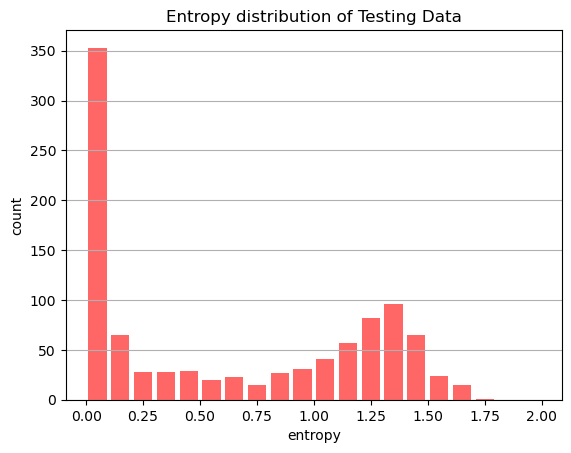

In [123]:
X_test = pd.read_csv('test_X.csv')
pred_probs = model.predict_proba(X_test)
entropies = np.apply_along_axis(entropy, 1, pred_probs)

plt.figure()
plt.grid(axis='y')
plt.hist(entropies, bins=bins, rwidth=0.8, alpha=0.6, color='red')
plt.xlabel('entropy')
plt.ylabel('count')
plt.title('Entropy distribution of Testing Data')
plt.show()

In [124]:
y_pred = [1 if entropy > 0.9 else 0 for entropy in entropies]
df = pd.DataFrame({
    'id': [i for i in range(1000)],
    'outliers': y_pred
})
df.to_csv('submission.csv', index=False)